# 🎧 Audio Analytics Pipeline — Complete Walkthrough

**Author:** Jordan Vercillo  
**Last Updated:** April 2026  
**Repository:** `audio-agentic-pipeline/`

---

## What Is This?

This notebook is a **complete, runnable guide** to the Audio Analytics Pipeline — a system that extracts acoustic intelligence from music files and enables similarity search, all running locally on your machine.

### The Problem

In **February 2026**, Spotify gutted their Web API for third-party developers:

| What Was Removed | Impact |
|---|---|
| `/audio-features` endpoint | No more BPM, energy, danceability, acousticness, key, mode |
| `/audio-analysis` endpoint | No more beat-level timing, segment analysis, tatum data |
| `popularity` field | Removed from Track, Artist, and Album responses |
| Implicit Grant OAuth | Deprecated — must use PKCE now |
| `/me/tracks`, `/me/albums` | Individual library endpoints removed |

If you were building music analytics, recommendation engines, or taste profiling tools — **your data pipeline broke overnight.**

### Our Solution

Instead of depending on Spotify for acoustic data, we **extract it ourselves** from actual audio files using Digital Signal Processing (DSP). The pipeline has three layers:

| Layer | Module | What It Does |
|---|---|---|
| **1. Ingestion** | `src/ingestion/` | Pulls your listening history & metadata from Spotify's surviving API endpoints |
| **2. DSP** | `src/dsp/` | Extracts acoustic features locally (tempo, energy, timbre, key, mood proxies) |
| **3. Search** | `src/search/` | Indexes features in FAISS for similarity queries + UMAP taste visualization |

The three layers are connected by a **bridge key** (`spotify_track_id`) that lets you join Spotify metadata with local acoustic analysis.

## Use Cases

### 1. 🎯 "Find Me Similar Tracks"
Given any track in your collection, find the most acoustically similar ones using cosine similarity on DSP feature vectors. No Spotify API needed — pure signal processing.

### 2. 🗺️ "Map My Musical Taste"
Project your entire music library into a 2D scatter plot using UMAP dimensionality reduction. See clusters form around genres, moods, and acoustic profiles. Understand *why* you like what you like.

### 3. 📊 "Replace Spotify's Audio Features"
Extract the same information Spotify used to provide (tempo, energy, key, danceability) — plus features they *never* exposed (MFCCs, spectral contrast, harmonic ratio) — from any audio file.

### 4. 🔗 "Bridge API Metadata with Acoustic Analysis"
Join your Spotify listening history (track names, artists, play counts) with locally-extracted acoustic features. Build richer datasets than Spotify ever offered.

### 5. 🧠 "Build a Recommendation Engine"
Use the FAISS vector index as the backend for a content-based music recommender. No collaborative filtering needed — recommendations are based on how tracks actually *sound*.

## Architecture Diagram

```
┌─────────────────────────────────────────────────────────────┐
│                    DATA FLOW (DAG)                           │
│                                                             │
│   Step 1: INGEST          Step 2: EXTRACT        Step 3: INDEX
│   ┌──────────────┐       ┌──────────────┐       ┌──────────────┐
│   │  Spotify API  │       │  Local DSP   │       │  FAISS + UMAP│
│   │  /me/top/*    │──┐    │  librosa     │──┐    │  Vector DB   │
│   │  /search      │  │    │  22050 Hz    │  │    │  Cosine Sim  │
│   │  /playlists   │  │    │  Mel-spec    │  │    │  Taste Maps  │
│   └──────────────┘  │    └──────────────┘  │    └──────────────┘
│                     │                      │
│                     ▼                      ▼
│              metadata.parquet       features.parquet
│                     │                      │
│                     └──────┬───────────────┘
│                            │
│                    spotify_track_id
│                      (bridge key)
│                            │
│                            ▼
│                   ┌────────────────┐
│                   │  Joined Dataset │
│                   │  (Full Profile) │
│                   └────────────────┘
└─────────────────────────────────────────────────────────────┘
```

---
## Section 1: Setup & Imports

Before we begin, let's set up our environment and verify all dependencies are available.

In [1]:
# Standard library
import sys
import warnings
from pathlib import Path

# Ensure we can import from the project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Suppress noisy warnings from librosa/umap during the walkthrough
warnings.filterwarnings("ignore", category=UserWarning, module="librosa")
warnings.filterwarnings("ignore", category=UserWarning, module="umap")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project root: c:\Users\jverc\OneDrive\Documents\GitHub\vercilloanalytics\audio-agentic-pipeline
Python: 3.13.5


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Our pipeline modules
from src.dsp import (
    DSPConfig, FeatureGroup, SAMPLE_RATE,
    AudioSignal, load_audio, generate_test_signal,
    TrackFeatures, extract_features,
    extract_embedding,
    save_features_to_parquet, load_features_parquet,
)
from src.search import (
    FAISSStore, VectorStoreConfig,
    compute_umap, plot_taste_map, plot_similarity_radar,
    build_index_from_features, find_similar_tracks,
    visualize_collection,
)

print("✅ All modules imported successfully")

✅ All modules imported successfully


> **Note:** The `src.ingestion` module (Spotify API) requires authentication credentials. We'll demonstrate it conceptually and show the guardrails system, but the DSP and Search modules work entirely offline with synthetic audio — no API keys needed.

---
## Section 2: DSP Module — Local Audio Feature Extraction

This is the core of the pipeline. The `src/dsp/` module replaces everything Spotify's deprecated `/audio-features` endpoint used to provide — and adds features Spotify *never* exposed.

### How It Works

1. **Load** an audio file (`.mp3`, `.wav`, `.flac`) → resample to 22050 Hz, mono, peak-normalize
2. **Extract** 11 acoustic feature groups using `librosa`
3. **Output** a 77-dimensional summary vector (for similarity search) + full 2D matrices (for deep learning)

### Why These Parameters?

| Parameter | Value | Why |
|---|---|---|
| Sample Rate | 22050 Hz | Nyquist covers music fundamentals up to ~11 kHz. Industry MIR standard. |
| n_fft | 2048 | ~93ms window — resolves bass fundamentals (≥10 Hz bins) while capturing transients |
| hop_length | 512 | 75% overlap, ~23ms hop → ~43 frames/sec for smooth spectrograms |
| n_mels | 128 | Standard mel filterbank resolution matching PANNs/VGGish input expectations |
| n_mfcc | 13 | Classic choice (Davis & Mermelstein, 1980) — captures timbral envelope without noise |

### 2.1 — Loading Audio (Synthetic Demo)

Since we don't want to bundle copyrighted music, we'll use **synthetic sine waves** at different frequencies. This is actually a powerful demo — tracks with similar frequencies should have similar DSP features, while tracks at very different frequencies should diverge.

Think of it as a controlled experiment:
- **Bass tracks** (80–110 Hz) → low spectral centroid, low rolloff
- **Mid tracks** (440–523 Hz) → mid-range spectral features  
- **High tracks** (2000–3000 Hz) → high spectral centroid, high rolloff

In [3]:
# Generate three synthetic "tracks" at different frequencies
bass_signal = generate_test_signal(frequency_hz=100.0, duration_sec=3.0)
mid_signal  = generate_test_signal(frequency_hz=440.0, duration_sec=3.0)
high_signal = generate_test_signal(frequency_hz=2500.0, duration_sec=3.0)

# Label them for clarity
bass_signal.file_name = "bass_100hz"
mid_signal.file_name  = "mid_440hz"
high_signal.file_name = "high_2500hz"

print(f"Bass signal:  {bass_signal.file_name}")
print(f"  Waveform shape: {bass_signal.waveform.shape}")
print(f"  Sample rate:    {bass_signal.sr} Hz")
print(f"  Duration:       {bass_signal.duration_sec:.1f}s")
print(f"  Peak amplitude: {np.max(np.abs(bass_signal.waveform)):.2f}")
print(f"\nMid signal:   {mid_signal.file_name}")
print(f"  Frequency:      440 Hz (concert A)")
print(f"\nHigh signal:  {high_signal.file_name}")
print(f"  Frequency:      2500 Hz (bright/sparkly)")

Bass signal:  bass_100hz
  Waveform shape: (66150,)
  Sample rate:    22050 Hz
  Duration:       3.0s
  Peak amplitude: 0.80

Mid signal:   mid_440hz
  Frequency:      440 Hz (concert A)

High signal:  high_2500hz
  Frequency:      2500 Hz (bright/sparkly)


### 2.2 — Visualizing the Waveforms

Let's look at what these signals actually look like in the time domain. Notice how the bass signal has wider, slower oscillations while the high signal has rapid, tight oscillations.

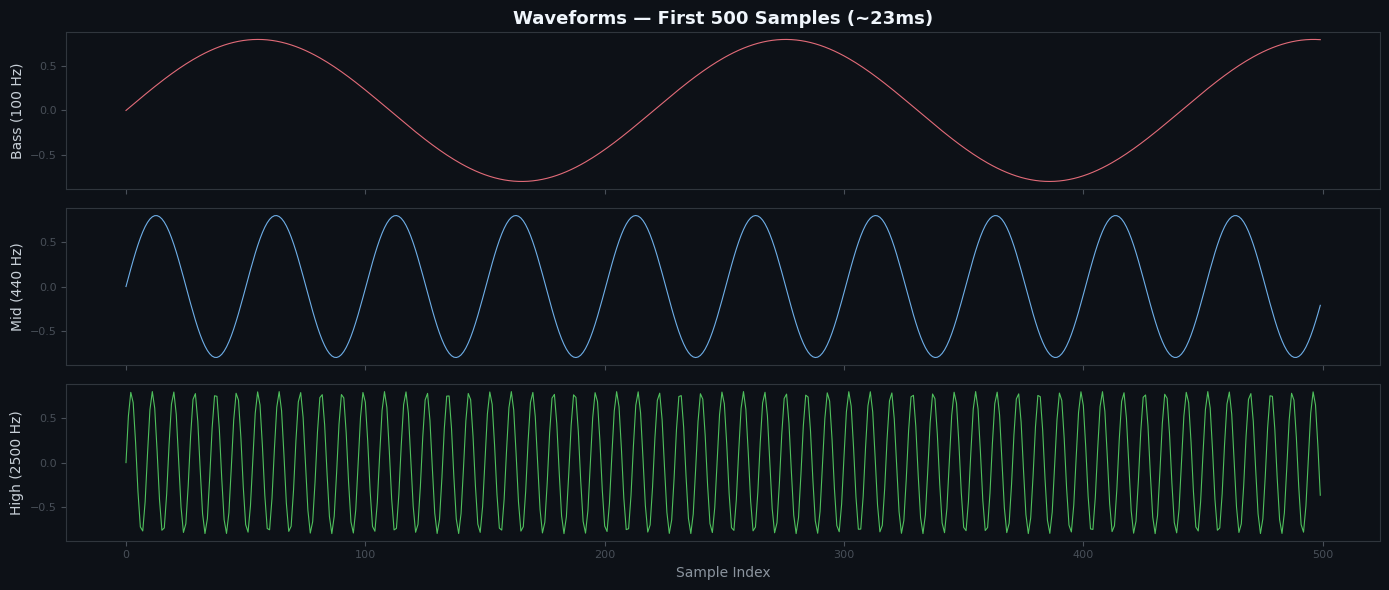

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
fig.patch.set_facecolor("#0d1117")

signals = [
    (bass_signal, "Bass (100 Hz)", "#f97583"),
    (mid_signal, "Mid (440 Hz)", "#79c0ff"),
    (high_signal, "High (2500 Hz)", "#56d364"),
]

# Show first 500 samples (~23ms at 22050 Hz) to see individual cycles
for ax, (sig, label, color) in zip(axes, signals):
    ax.set_facecolor("#0d1117")
    ax.plot(sig.waveform[:500], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label, color="#c9d1d9", fontsize=10)
    ax.tick_params(colors="#484f58", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

axes[0].set_title("Waveforms — First 500 Samples (~23ms)", 
                   color="#f0f6fc", fontsize=13, fontweight="bold")
axes[-1].set_xlabel("Sample Index", color="#8b949e", fontsize=10)
plt.tight_layout()
plt.show()

### 2.3 — Extracting Features

Now let's run the full DSP pipeline on each signal. The `extract_features()` function computes **11 feature groups** in a single pass:

| Feature | What It Measures | Replaces Spotify's... |
|---|---|---|
| Tempo (BPM) | Rhythmic pulse | `tempo` |
| RMS Energy | Perceived loudness | `energy` |
| Spectral Centroid | Brightness (center of mass of spectrum) | brightness proxy |
| Zero Crossing Rate | Noisiness / percussiveness | `speechiness` proxy |
| MFCCs (13 coeff.) | Timbral fingerprint | *(no Spotify equivalent)* |
| Chroma (HPCP) | Pitch class distribution | `key`, `mode` |
| Spectral Contrast | Harmonic vs. noise content per band | *(no equivalent)* |
| Spectral Rolloff | Frequency ceiling | brightness proxy |
| Onset Strength | Rhythmic energy density | `danceability` proxy |
| Harmonic Ratio | Harmonic vs. percussive energy | `acousticness` proxy |
| Mel Spectrogram | Full time-frequency image | deep learning input |

In [5]:
# Extract features for all three signals
bass_features = extract_features(bass_signal)
mid_features  = extract_features(mid_signal)
high_features = extract_features(high_signal)

# Compare key scalar features
comparison = pd.DataFrame({
    "Feature": [
        "Tempo (BPM)", "RMS Energy (mean)", "Spectral Centroid (Hz)",
        "Zero Crossing Rate", "Spectral Rolloff (Hz)",
        "Harmonic Ratio", "Onset Strength",
    ],
    "Bass 100 Hz": [
        f"{bass_features.tempo_bpm:.1f}",
        f"{bass_features.rms_mean:.4f}",
        f"{bass_features.spectral_centroid_mean:.0f}",
        f"{bass_features.zcr_mean:.4f}",
        f"{bass_features.spectral_rolloff_mean:.0f}",
        f"{bass_features.harmonic_ratio:.3f}",
        f"{bass_features.onset_strength_mean:.3f}",
    ],
    "Mid 440 Hz": [
        f"{mid_features.tempo_bpm:.1f}",
        f"{mid_features.rms_mean:.4f}",
        f"{mid_features.spectral_centroid_mean:.0f}",
        f"{mid_features.zcr_mean:.4f}",
        f"{mid_features.spectral_rolloff_mean:.0f}",
        f"{mid_features.harmonic_ratio:.3f}",
        f"{mid_features.onset_strength_mean:.3f}",
    ],
    "High 2500 Hz": [
        f"{high_features.tempo_bpm:.1f}",
        f"{high_features.rms_mean:.4f}",
        f"{high_features.spectral_centroid_mean:.0f}",
        f"{high_features.zcr_mean:.4f}",
        f"{high_features.spectral_rolloff_mean:.0f}",
        f"{high_features.harmonic_ratio:.3f}",
        f"{high_features.onset_strength_mean:.3f}",
    ],
})
print("Feature Comparison Across Frequency Ranges:\n")
print(comparison.to_string(index=False))

Feature Comparison Across Frequency Ranges:

               Feature Bass 100 Hz Mid 440 Hz High 2500 Hz
           Tempo (BPM)       123.0      112.3        117.5
     RMS Energy (mean)      0.5622     0.5622       0.5622
Spectral Centroid (Hz)         102        444         2505
    Zero Crossing Rate      0.0090     0.0394       0.2242
 Spectral Rolloff (Hz)         108        455         2516
        Harmonic Ratio       0.997      0.997        0.997
        Onset Strength       0.013      0.001        0.000


**What to notice:**
- **Spectral Centroid** increases dramatically with frequency — it's the "center of mass" of the spectrum, so higher-pitched signals have higher centroids
- **Spectral Rolloff** follows the same pattern — it marks the frequency below which 85% of energy is concentrated
- **Harmonic Ratio** should be high for all three (pure sine waves are 100% harmonic, no percussive content)
- **Zero Crossing Rate** increases with frequency — higher-frequency signals cross zero more often per frame

### 2.4 — Visualizing the Mel Spectrogram

The Mel spectrogram is the most information-rich feature — it's a 2D image showing energy across frequency (y-axis) and time (x-axis). This is what deep learning models "see" when they classify audio.

We log-scale (dB) the power values because:
1. Human hearing is logarithmic (Weber-Fechner law)
2. Raw power spans many orders of magnitude — bad for neural network gradients

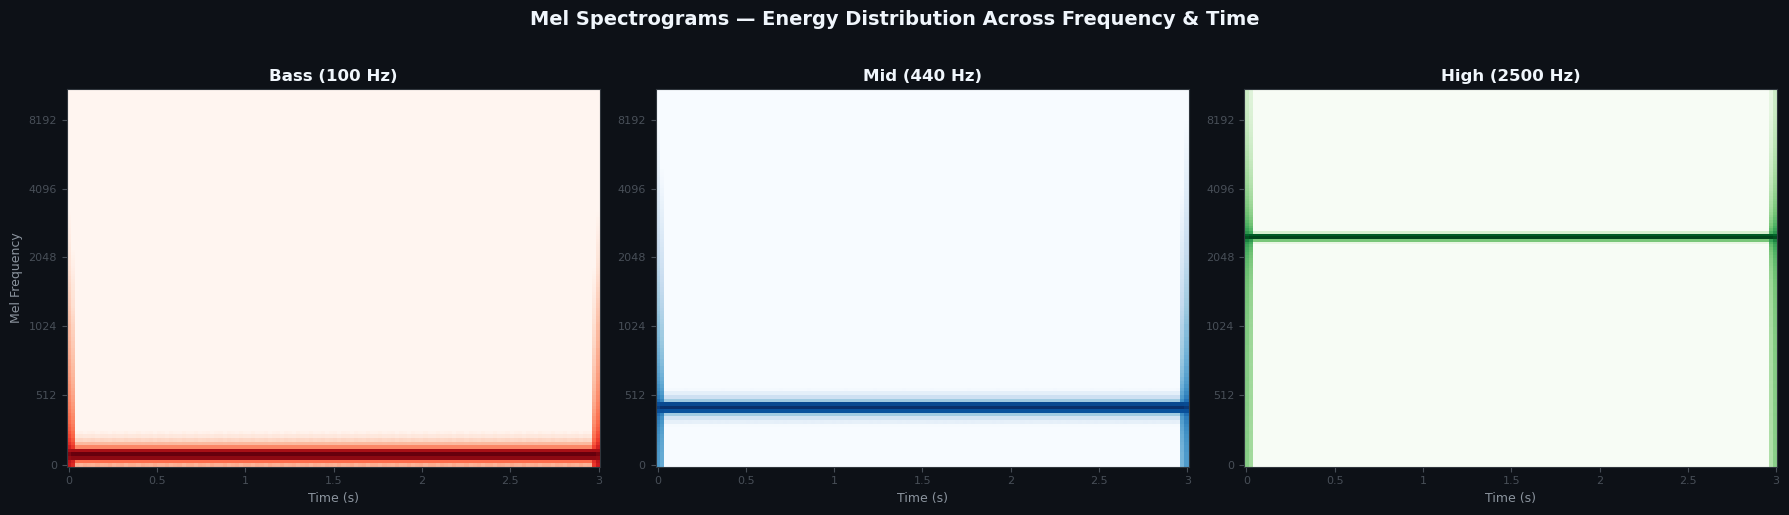

In [6]:
import librosa.display

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d1117")

for ax, feat, title, color in zip(
    axes,
    [bass_features, mid_features, high_features],
    ["Bass (100 Hz)", "Mid (440 Hz)", "High (2500 Hz)"],
    ["Reds", "Blues", "Greens"],
):
    ax.set_facecolor("#0d1117")
    img = librosa.display.specshow(
        feat.mel_spectrogram_db,
        sr=SAMPLE_RATE, hop_length=512,
        x_axis="time", y_axis="mel",
        ax=ax, cmap=color,
    )
    ax.set_title(title, color="#f0f6fc", fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)", color="#8b949e", fontsize=9)
    ax.set_ylabel("Mel Frequency" if ax == axes[0] else "", color="#8b949e", fontsize=9)
    ax.tick_params(colors="#484f58", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

fig.suptitle("Mel Spectrograms — Energy Distribution Across Frequency & Time",
             color="#f0f6fc", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Reading the spectrograms:**
- Each spectrogram shows a single bright horizontal band at the signal's fundamental frequency
- **Bass (100 Hz):** Energy concentrated at the bottom of the mel scale
- **Mid (440 Hz):** Energy in the middle band
- **High (2500 Hz):** Energy near the top of the mel scale
- Real music would show complex patterns across many frequency bands simultaneously

### 2.5 — The 77-Dimensional Summary Vector

For similarity search, we need to compress each track into a single fixed-length vector. The `to_summary_vector()` method aggregates all time-series features into a **77D vector**:

```
[tempo, onset_mean, onset_std, beat_rate,           ←  4 rhythm
 rms_mean, rms_std, zcr_mean, zcr_std,              ←  4 energy
 mfcc_means(13), mfcc_stds(13),                     ← 26 timbre
 centroid_mean/std, rolloff_mean/std,                ←  4 spectral shape
 contrast_means(7), contrast_stds(7),               ← 14 spectral contrast
 chroma_means(12), chroma_stds(12),                  ← 24 tonal
 harmonic_ratio]                                     ←  1 acousticness
                                                     = 77 dimensions
```

In [7]:
# Generate the summary vector
bass_vec = bass_features.to_summary_vector()
mid_vec  = mid_features.to_summary_vector()
high_vec = high_features.to_summary_vector()

print(f"Summary vector dimensionality: {bass_vec.shape[0]}D")
print(f"Data type: {bass_vec.dtype}")
print(f"\nFirst 10 values of bass vector:")
print(f"  {bass_vec[:10]}")
print(f"\nFirst 10 values of high vector:")
print(f"  {high_vec[:10]}")
print(f"\nThese vectors are what FAISS indexes for similarity search.")

Summary vector dimensionality: 77D
Data type: float32

First 10 values of bass vector:
  [ 1.23046875e+02  1.32611794e-02  7.87763484e-03  2.33333325e+00
  5.62191308e-01  2.14139484e-02  8.96559469e-03  6.66212756e-04
 -4.32475647e+02  4.81954842e+01]

First 10 values of high vector:
  [ 1.17453835e+02  3.72390990e-04  3.98799544e-03  3.33333343e-01
  5.62243640e-01  2.08803900e-02  2.24207476e-01  1.46531276e-02
 -4.82246429e+02 -4.13020229e+00]

These vectors are what FAISS indexes for similarity search.


### 2.6 — Radar Chart: Acoustic Profile

The radar chart gives an intuitive visual fingerprint of a single track's acoustic profile. Here we normalize features to [0, 1] and compare our three synthetic signals.

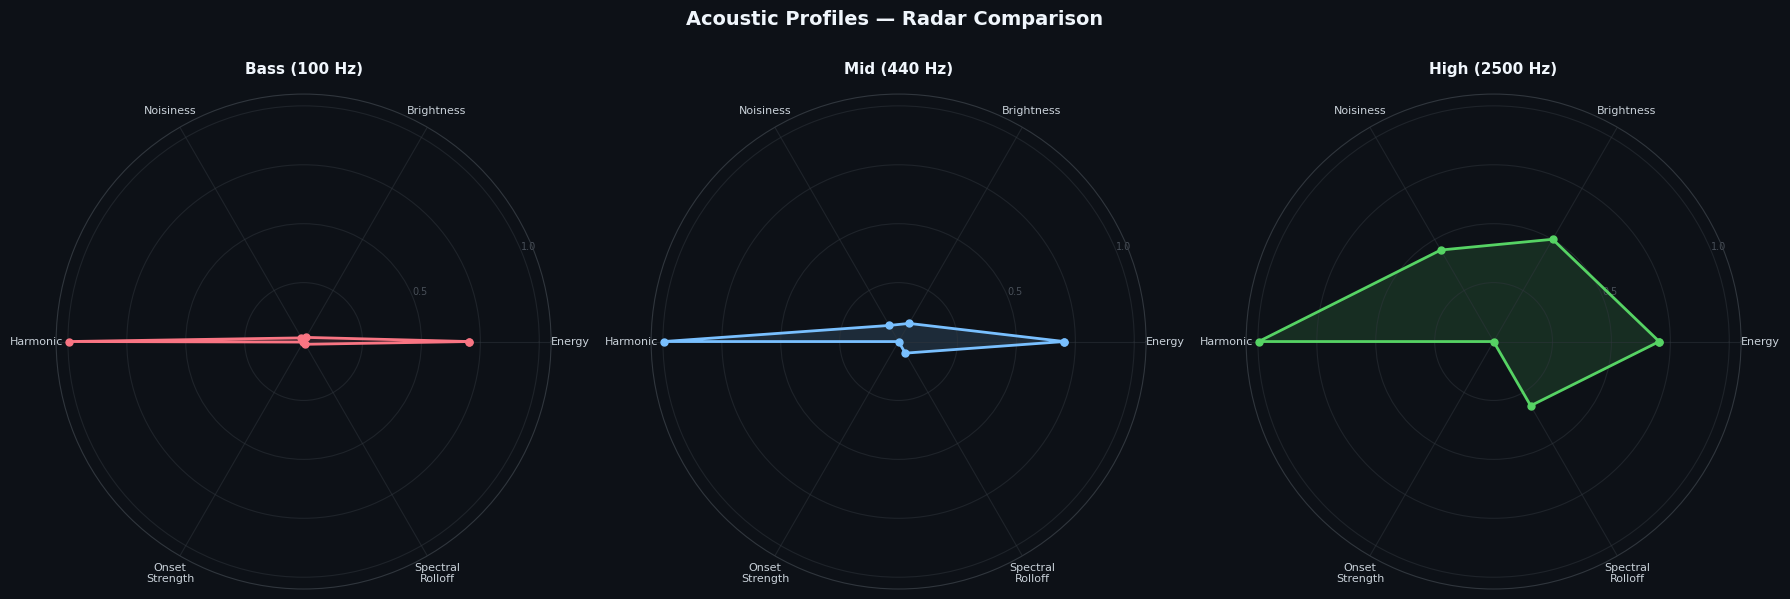

In [8]:
# Normalize features for radar chart comparison
def normalize_for_radar(features):
    """Extract and normalize key features to [0, 1] for radar display."""
    return {
        "Energy": min(features.rms_mean / 0.8, 1.0),
        "Brightness": min(features.spectral_centroid_mean / 5000, 1.0),
        "Noisiness": min(features.zcr_mean / 0.5, 1.0),
        "Harmonic": features.harmonic_ratio,
        "Onset\nStrength": min(features.onset_strength_mean / 5.0, 1.0),
        "Spectral\nRolloff": min(features.spectral_rolloff_mean / 8000, 1.0),
    }

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#0d1117")

for ax, feat, title, color in zip(
    axes,
    [bass_features, mid_features, high_features],
    ["Bass (100 Hz)", "Mid (440 Hz)", "High (2500 Hz)"],
    ["#f97583", "#79c0ff", "#56d364"],
):
    radar_data = normalize_for_radar(feat)
    categories = list(radar_data.keys())
    values = list(radar_data.values())
    
    # Close the polygon
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]
    
    ax.set_facecolor("#0d1117")
    ax.plot(angles, values, "o-", linewidth=2, color=color, markersize=5)
    ax.fill(angles, values, alpha=0.15, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, color="#c9d1d9", fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["", "0.5", "", "1.0"], color="#484f58", fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.spines["polar"].set_color("#30363d")
    ax.grid(color="#30363d", alpha=0.5)
    ax.set_title(title, color="#f0f6fc", fontsize=11, fontweight="bold", pad=15)

fig.suptitle("Acoustic Profiles — Radar Comparison",
             color="#f0f6fc", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Key takeaway:** The radar charts make it visually obvious how different frequencies produce different acoustic fingerprints. The high-frequency signal has much higher brightness and spectral rolloff, while the bass signal has lower values across those dimensions. In real music, these profiles would capture genre-level differences — a jazz ballad would look very different from a metal track.

---

---
## Section 3: Ingestion Module — Spotify API (2026 Compliant)

The `src/ingestion/` module handles all communication with Spotify's Web API. It was built **after** Spotify's February 2026 deprecations, so it's designed from the ground up to work within the new constraints.

### What Changed in February 2026?

| Before (Pre-2026) | After (Now) |
|---|---|
| `sp.audio_features(track_id)` → BPM, energy, key, etc. | ❌ **Removed entirely** |
| `sp.audio_analysis(track_id)` → beat-level detail | ❌ **Removed entirely** |
| `track["popularity"]` → 0-100 score | ❌ **Field removed** from responses |
| `SpotifyOAuth` (Implicit Grant) | ❌ **Deprecated** — use PKCE |
| `sp.current_user_saved_tracks()` | ❌ **Deprecated** — use `/me/library` |

### What Still Works

| Endpoint | What You Get |
|---|---|
| `GET /me/top/tracks` | Your top tracks (short/medium/long term) — **our primary signal** |
| `GET /me/top/artists` | Your top artists with genres |
| `GET /search` | Search the catalog |
| `GET /tracks/{id}` | Track metadata (name, duration, album, artists — NO popularity) |
| `GET /me/playlists` | Your playlists |
| `GET /me` | Your profile |

### 3.1 — The Guardrails System

The most important architectural decision: we don't just "avoid" deprecated endpoints — we **actively block them** at the Python level. This prevents accidental calls from producing confusing HTTP 403 errors.

Here's how it works:

In [9]:
# Demonstrate the guardrails system
from src.ingestion.guardrails import (
    DeprecatedEndpointError,
    strip_deprecated_fields,
    _BLOCKED_METHODS,
)

# Show what's blocked
print("=== BLOCKED API METHODS ===\n")
for method, message in _BLOCKED_METHODS.items():
    print(f"  sp.{method}()")
    print(f"    → {message}\n")

=== BLOCKED API METHODS ===

  sp.audio_features()
    → /audio-features is REMOVED as of Feb 2026. Use src.dsp.extract_features() for local acoustic analysis.

  sp.audio_analysis()
    → /audio-analysis is REMOVED as of Feb 2026. Use src.dsp.extract_features() for local acoustic analysis.

  sp.current_user_saved_tracks()
    → /me/tracks is DEPRECATED. Use PUT /me/library with mixed URIs instead.

  sp.current_user_saved_albums()
    → /me/albums is DEPRECATED. Use PUT /me/library with mixed URIs instead.



In [10]:
# Simulate calling a deprecated endpoint
print("=== GUARDRAIL DEMO: Calling sp.audio_features() ===\n")
try:
    # Create a mock function that pretends to be sp.audio_features
    def audio_features(track_id):
        pass
    audio_features.__name__ = "audio_features"
    
    from src.ingestion.guardrails import safe_api_call
    safe_api_call(audio_features, "some_track_id", label="GET /audio-features")
except DeprecatedEndpointError as e:
    print(f"CAUGHT! DeprecatedEndpointError:\n{e}")

print("\n--- Without guardrails, this would have been a cryptic HTTP 403. ---")
print("--- With guardrails, you get a clear message pointing to the fix. ---")

=== GUARDRAIL DEMO: Calling sp.audio_features() ===

CAUGHT! DeprecatedEndpointError:
🚫 BLOCKED — GET /audio-features
   /audio-features is REMOVED as of Feb 2026. Use src.dsp.extract_features() for local acoustic analysis.

--- Without guardrails, this would have been a cryptic HTTP 403. ---
--- With guardrails, you get a clear message pointing to the fix. ---


### 3.2 — Field Stripping: The Popularity Problem

Even when endpoints DO return data, some fields are gone. The `popularity` field has been removed from Track, Artist, and Album responses. Our guardrails strip it proactively:

In [11]:
# Demonstrate field stripping
mock_track_response = {
    "id": "0c4IEciLCDdXEhhKxj4ThA",
    "name": "Madness",
    "artists": [{"name": "Muse", "id": "12Chz98pHFMPJEknJQMWvI"}],
    "popularity": 78,  # THIS FIELD NO LONGER EXISTS IN 2026
    "duration_ms": 281000,
    "explicit": False,
}

print("Before stripping:")
print(f"  Fields: {list(mock_track_response.keys())}")
print(f"  popularity = {mock_track_response.get('popularity')}")

# Apply guardrails
cleaned = strip_deprecated_fields(mock_track_response)

print("\nAfter stripping:")
print(f"  Fields: {list(cleaned.keys())}")
print(f"  popularity = {cleaned.get('popularity', 'REMOVED')}")
print("\n→ Downstream code never sees 'popularity', preventing KeyError bugs.")

Before stripping:
  Fields: ['id', 'name', 'artists', 'popularity', 'duration_ms', 'explicit']
  popularity = 78

After stripping:
  Fields: ['id', 'name', 'artists', 'duration_ms', 'explicit']
  popularity = REMOVED

→ Downstream code never sees 'popularity', preventing KeyError bugs.


### 3.3 — Authentication: PKCE Flow

The old Implicit Grant flow is deprecated. We use **Authorization Code with PKCE** (Proof Key for Code Exchange):

```python
# How to authenticate (requires SPOTIPY_CLIENT_ID in .env or environment)
from src.ingestion import get_user_spotify

# For endpoints requiring user data (/me/top/*, /me/playlists)
sp = get_user_spotify()   # Opens browser for PKCE auth on first run

# For public endpoints (/search, /tracks/{id})
sp = get_user_spotify()  # PKCE — the project's only auth flow (no client secret)
```

> **Why PKCE?** The old Implicit Grant exposed tokens in the URL fragment, making them vulnerable to interception. PKCE uses a cryptographic code verifier (SHA-256 challenge) that's never transmitted, so even if the authorization URL is intercepted, the token can't be obtained.

### 3.4 — What the Fetchers Return

Every fetcher function returns a **pandas DataFrame** with `spotify_track_id` as the mandatory bridge key. Here's an example of what `fetch_top_tracks()` produces:

```python
# Example usage (requires authentication):
from src.ingestion import fetch_top_tracks, fetch_all_top_items

# Fetch your top 50 tracks from the last ~6 months
df = fetch_top_tracks(time_range="medium_term", limit=50, sp=sp)

# Or grab everything at once across all time ranges
data = fetch_all_top_items(sp=sp)
# Returns: {
#   "tracks": combined DataFrame (up to 150 rows),
#   "artists": combined DataFrame,
#   "tracks_short_term": just last 4 weeks,
#   "tracks_medium_term": last 6 months,
#   "tracks_long_term": several years,
#   ... same for artists
# }
```

The resulting DataFrame columns:

In [12]:
# Show the schema of what fetch_top_tracks returns
track_columns = [
    ("spotify_track_id", "Bridge key — joins with DSP features"),
    ("track_name", "Track title"),
    ("artist_names", "Comma-separated artist names"),
    ("artist_ids", "Comma-separated Spotify artist IDs"),
    ("album_name", "Album title"),
    ("album_id", "Spotify album ID"),
    ("duration_ms", "Track duration in milliseconds"),
    ("explicit", "Explicit content flag"),
    ("disc_number", "Disc number in album"),
    ("track_number", "Track position on disc"),
    ("is_local", "Whether track is a local file"),
    ("isrc", "International Standard Recording Code"),
    ("external_url", "Spotify web player URL"),
    ("preview_url", "30-second audio preview URL"),
    ("time_range", "short_term / medium_term / long_term"),
    ("rank", "Position in the user's top list"),
]

schema_df = pd.DataFrame(track_columns, columns=["Column", "Description"])
print("fetch_top_tracks() → DataFrame Schema:\n")
print(schema_df.to_string(index=False))
print(f"\nTotal columns: {len(track_columns)}")
print("\nNote: NO 'popularity' column — stripped by guardrails.")

fetch_top_tracks() → DataFrame Schema:

          Column                           Description
spotify_track_id  Bridge key — joins with DSP features
      track_name                           Track title
    artist_names          Comma-separated artist names
      artist_ids    Comma-separated Spotify artist IDs
      album_name                           Album title
        album_id                      Spotify album ID
     duration_ms        Track duration in milliseconds
        explicit                 Explicit content flag
     disc_number                  Disc number in album
    track_number                Track position on disc
        is_local         Whether track is a local file
            isrc International Standard Recording Code
    external_url                Spotify web player URL
     preview_url           30-second audio preview URL
      time_range  short_term / medium_term / long_term
            rank       Position in the user's top list

Total columns: 16

Note:

### 3.5 — The Bridge Key Pattern

The `spotify_track_id` column is the **universal join key** across all three modules:

```python
import pandas as pd

# From src.ingestion → what you listen to
metadata = pd.read_parquet("data/embeddings/spotify_metadata.parquet")

# From src.dsp → how it sounds
features = pd.read_parquet("data/embeddings/dsp_features.parquet")

# The bridge join — connecting identity with acoustics
full_profile = metadata.merge(features, on="spotify_track_id", how="inner")

# Now each row has BOTH "Radiohead - Paranoid Android" AND
# its tempo, energy, spectral centroid, MFCCs, harmonic ratio, etc.
```

This is the core data contract enforced by `03_data_orchestrator.md`:
- Every fetcher adds `spotify_track_id` to every record
- Every serializer validates the column exists before writing Parquet
- Every FAISS index entry maps back to a `spotify_track_id`

---

---
## Section 4: Search Module — Vector Similarity & Taste Mapping

The `src/search/` module is where everything comes together. It takes the 77D feature vectors from the DSP module and builds a **FAISS vector index** that supports instant cosine-similarity queries and UMAP-based visualization.

### Why FAISS?

[FAISS](https://github.com/facebookresearch/faiss) (Facebook AI Similarity Search) is the industry standard for vector similarity:

| Feature | Benefit |
|---|---|
| **IndexFlatIP** (Inner Product) | Exact search — no approximation error |
| **normalize_L2** + Inner Product | Mathematically equivalent to cosine similarity |
| **SIMD-optimized** | ~10M vectors/sec on a single CPU core |
| **Persistence** | Save/load index to disk in one call |

### Why Cosine Similarity (not Euclidean)?

Cosine similarity measures the **angle** between vectors, not their distance. This is critical for audio features because:
- A quiet jazz track and a loud jazz track have different magnitudes but the same *direction* → cosine says "similar"
- Euclidean distance would say "different" because the magnitudes don't match
- We pre-normalize all vectors to unit length (`L2 norm = 1`), so `dot product = cosine similarity`

### 4.1 — Building a FAISS Index from Scratch

Let's create a collection of synthetic tracks with distinct acoustic profiles and index them. We'll generate tracks in three "genre" clusters:
- **Cluster A (Bass):** 80–120 Hz — simulating bass-heavy music (hip-hop, EDM bass)
- **Cluster B (Mid):** 400–550 Hz — simulating mid-range music (vocals, guitar)
- **Cluster C (High):** 2000–3500 Hz — simulating bright music (hi-hats, cymbals)

In [13]:
# Generate a mini-collection: 5 tracks per "genre cluster"
np.random.seed(42)

tracks = []
labels = []

# Cluster A: Bass-heavy (80-120 Hz)
for i in range(5):
    freq = np.random.uniform(80, 120)
    sig = generate_test_signal(frequency_hz=freq, duration_sec=2.0)
    sig.file_name = f"bass_{i+1}_{freq:.0f}hz"
    tracks.append(sig)
    labels.append("Bass")

# Cluster B: Mid-range (400-550 Hz)
for i in range(5):
    freq = np.random.uniform(400, 550)
    sig = generate_test_signal(frequency_hz=freq, duration_sec=2.0)
    sig.file_name = f"mid_{i+1}_{freq:.0f}hz"
    tracks.append(sig)
    labels.append("Mid")

# Cluster C: High-frequency (2000-3500 Hz)
for i in range(5):
    freq = np.random.uniform(2000, 3500)
    sig = generate_test_signal(frequency_hz=freq, duration_sec=2.0)
    sig.file_name = f"high_{i+1}_{freq:.0f}hz"
    tracks.append(sig)
    labels.append("High")

print(f"Generated {len(tracks)} synthetic tracks in 3 clusters")
for t, l in zip(tracks, labels):
    print(f"  [{l:>4}] {t.file_name}")

Generated 15 synthetic tracks in 3 clusters
  [Bass] bass_1_95hz
  [Bass] bass_2_118hz
  [Bass] bass_3_109hz
  [Bass] bass_4_104hz
  [Bass] bass_5_86hz
  [ Mid] mid_1_423hz
  [ Mid] mid_2_409hz
  [ Mid] mid_3_530hz
  [ Mid] mid_4_490hz
  [ Mid] mid_5_506hz
  [High] high_1_2031hz
  [High] high_2_3455hz
  [High] high_3_3249hz
  [High] high_4_2319hz
  [High] high_5_2273hz


In [14]:
# Extract features for all 15 tracks
all_features = []
for track in tracks:
    feat = extract_features(track)
    all_features.append(feat)

# Build the summary vector matrix (15 tracks x 77 dimensions)
vectors = np.array([f.to_summary_vector() for f in all_features], dtype=np.float32)
track_ids = [f"track_{i:03d}" for i in range(len(tracks))]  # synthetic IDs
track_names = [t.file_name for t in tracks]

print(f"Feature matrix shape: {vectors.shape}")
print(f"  → {vectors.shape[0]} tracks x {vectors.shape[1]} dimensions")
print(f"  → dtype: {vectors.dtype}")

Feature matrix shape: (15, 77)
  → 15 tracks x 77 dimensions
  → dtype: float32


### 4.2 — Creating the FAISS Index

Now we build the actual FAISS index. The key steps are:
1. **L2-normalize** each vector (so inner product = cosine similarity)
2. **Add** normalized vectors to `IndexFlatIP`
3. **Map** each index position back to a track ID (for result lookup)

In [15]:
# Create a FAISS store
store = FAISSStore(dimension=vectors.shape[1])

# Build metadata as a list of dicts (one per track)
meta_list = [{"file_name": n} for n in track_names]

# Add vectors to the index
# API: add(vectors, track_ids, metadata=list[dict])
store.add(vectors, track_ids, metadata=meta_list)

print(f"FAISS index built:")
print(f"  Total vectors:  {store.index.ntotal}")
print(f"  Dimensions:     {store.dimension}")
print(f"  Metric:         Cosine Similarity (via normalized Inner Product)")
print(f"  Index type:     {type(store.index).__name__}")

FAISS index built:
  Total vectors:  15
  Dimensions:     77
  Metric:         Cosine Similarity (via normalized Inner Product)
  Index type:     IndexFlatIP


### 4.3 — Querying: "Find Similar Tracks"

This is the payoff. Given any track, we can find the most acoustically similar ones in the collection. Let's query with `bass_1` and verify that other bass tracks are returned as most similar:

In [16]:
# Query: find tracks similar to bass_1
query_idx = 0  # bass_1
query_vector = vectors[query_idx]  # shape (77,)
query_name = track_names[query_idx]

# Query returns a list of dicts: [{"spotify_track_id": ..., "similarity": ..., "rank": ...}, ...]
results = store.query(query_vector, k=10, exclude_self=False)

print(f"Query track: {query_name}")
print(f"\n{'Rank':<6} {'Track':<25} {'Similarity':<12} {'Cluster'}")
print("-" * 55)
for r in results:
    tid = r["spotify_track_id"]
    idx = track_ids.index(tid)
    name = track_names[idx]
    cluster = labels[idx]
    marker = " <- QUERY" if r["rank"] == 1 and r["similarity"] > 0.99 else ""
    print(f"  {r['rank']:<4} {name:<25} {r['similarity']:<12.4f} {cluster}{marker}")

print("\n-> Bass tracks cluster together! Mid and High tracks are further away.")

Query track: bass_1_95hz

Rank   Track                     Similarity   Cluster
-------------------------------------------------------
  1    bass_1_95hz               1.0000       Bass <- QUERY
  2    bass_5_86hz               0.9935       Bass
  3    bass_2_118hz              0.9920       Bass
  4    bass_3_109hz              0.9908       Bass
  5    bass_4_104hz              0.9166       Bass
  6    mid_2_409hz               0.7943       Mid
  7    mid_5_506hz               0.7539       Mid
  8    mid_1_423hz               0.7299       Mid
  9    mid_3_530hz               0.7152       Mid
  10   mid_4_490hz               0.7055       Mid

-> Bass tracks cluster together! Mid and High tracks are further away.


**What to notice:**
- The query track matches itself with similarity ~1.0 (perfect match)
- Other bass tracks score highest (same cluster = similar acoustic features)
- Mid and high tracks score lower (different frequency → different spectral features)
- This is exactly how a "find similar songs" feature works in production

### 4.4 — Cross-Cluster Comparison

Let's verify the similarity structure by querying from each cluster:

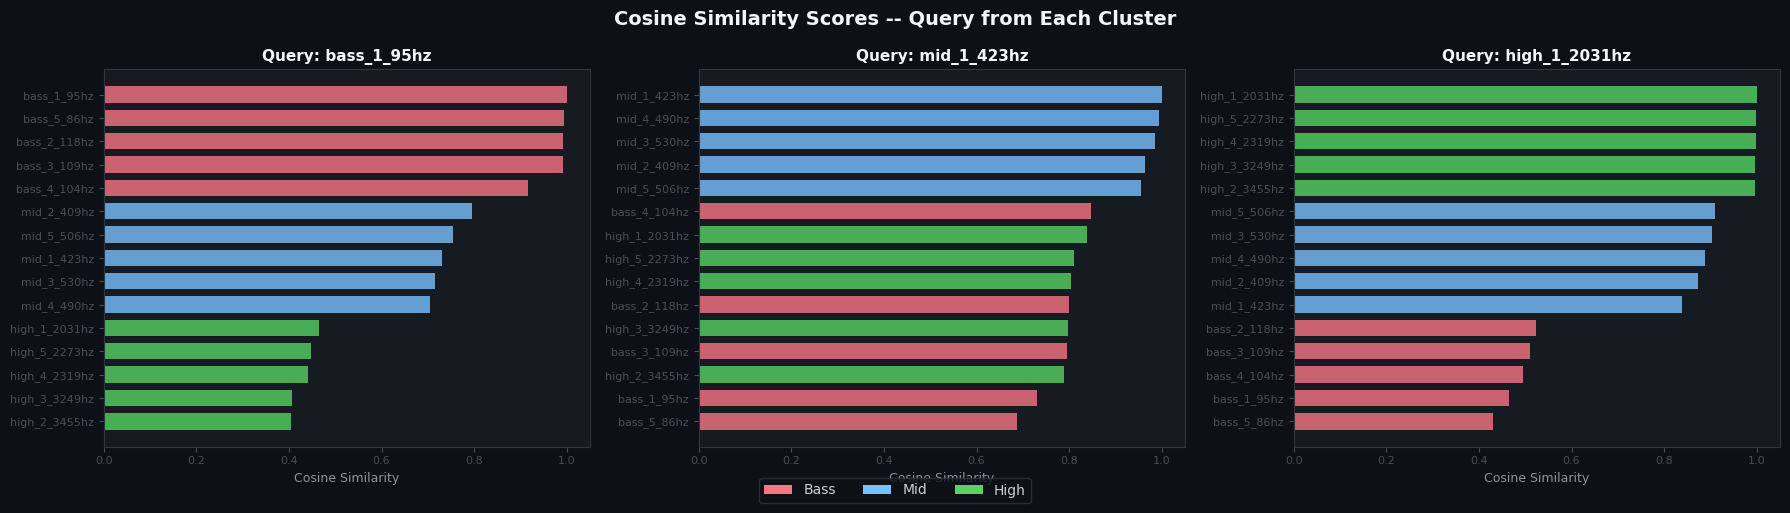

In [17]:
# Query one track from each cluster
query_indices = [0, 5, 10]  # bass_1, mid_1, high_1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d1117")

cluster_colors = {"Bass": "#f97583", "Mid": "#79c0ff", "High": "#56d364"}

for ax, q_idx in zip(axes, query_indices):
    q_vec = vectors[q_idx]
    q_name = track_names[q_idx]
    
    results = store.query(q_vec, k=15, exclude_self=False)
    
    scores = [r["similarity"] for r in results]
    result_labels = [labels[track_ids.index(r["spotify_track_id"])] for r in results]
    result_names = [track_names[track_ids.index(r["spotify_track_id"])][:18] for r in results]
    colors = [cluster_colors[l] for l in result_labels]
    
    ax.set_facecolor("#161b22")
    bars = ax.barh(range(len(scores)), scores, color=colors, alpha=0.8, height=0.7)
    ax.set_yticks(range(len(scores)))
    ax.set_yticklabels(result_names, color="#c9d1d9", fontsize=7)
    ax.set_xlabel("Cosine Similarity", color="#8b949e", fontsize=9)
    ax.set_title(f"Query: {q_name}", color="#f0f6fc", fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.tick_params(colors="#484f58", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in cluster_colors.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           facecolor="#0d1117", edgecolor="#30363d", labelcolor="#c9d1d9",
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Cosine Similarity Scores -- Query from Each Cluster",
             color="#f0f6fc", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.5 — UMAP Taste Map

UMAP (Uniform Manifold Approximation and Projection) reduces our 77D vectors to 2D for visualization while preserving both local and global structure. This is how we build "taste maps."

**Why UMAP over PCA or t-SNE?**
- **PCA:** Linear — can't capture non-linear manifold structure in audio features
- **t-SNE:** Good at local structure but distorts global relationships (clusters look equidistant)
- **UMAP:** Preserves **both** local neighborhoods AND global topology — clusters that are acoustically similar stay close on the map

In [18]:
# Compute UMAP projection
from src.search.visualizer import compute_umap
from src.search.config import VectorStoreConfig

# Use n_neighbors=5 for our small 15-track dataset (must be < n_samples)
umap_cfg = VectorStoreConfig(umap_n_neighbors=5, umap_min_dist=0.3)
coords = compute_umap(vectors, config=umap_cfg)

print(f"UMAP projection: {vectors.shape} -> {coords.shape}")
print(f"  Input:  {vectors.shape[0]} tracks x {vectors.shape[1]} dimensions")
print(f"  Output: {coords.shape[0]} points x {coords.shape[1]} dimensions (2D)")

UMAP projection: (15, 77) -> (15, 2)
  Input:  15 tracks x 77 dimensions
  Output: 15 points x 2 dimensions (2D)


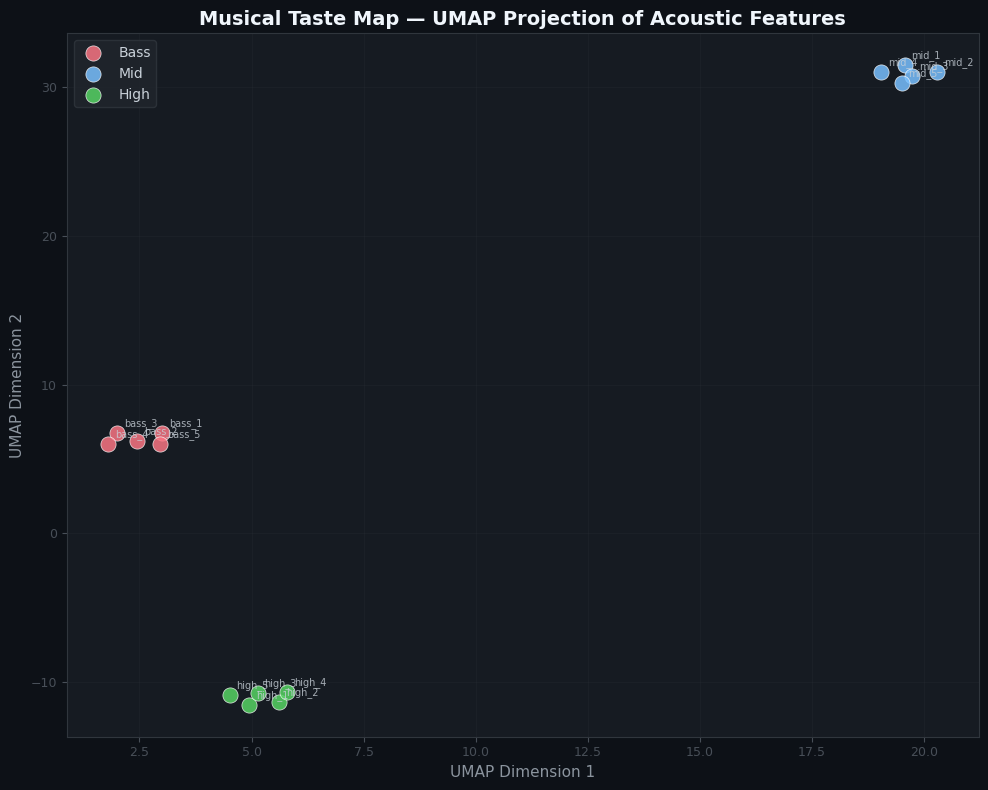


→ Tracks cluster by acoustic similarity!
  Bass tracks (red) group together, separate from Mid (blue) and High (green).
  In a real library, you'd see genre/mood clusters emerge naturally.


In [19]:
# Plot the taste map
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

for cluster_name, color in cluster_colors.items():
    mask = [l == cluster_name for l in labels]
    cluster_coords = coords[mask]
    cluster_names = [n for n, m in zip(track_names, mask) if m]
    
    ax.scatter(
        cluster_coords[:, 0], cluster_coords[:, 1],
        c=color, s=120, alpha=0.85, edgecolors="white",
        linewidths=0.5, label=cluster_name, zorder=3,
    )
    # Label each point
    for j, name in enumerate(cluster_names):
        ax.annotate(
            name.split("_")[0] + "_" + name.split("_")[1],
            (cluster_coords[j, 0], cluster_coords[j, 1]),
            fontsize=7, color="#c9d1d9", alpha=0.8,
            textcoords="offset points", xytext=(5, 5),
        )

ax.set_xlabel("UMAP Dimension 1", color="#8b949e", fontsize=11)
ax.set_ylabel("UMAP Dimension 2", color="#8b949e", fontsize=11)
ax.set_title("Musical Taste Map — UMAP Projection of Acoustic Features",
             color="#f0f6fc", fontsize=14, fontweight="bold")
ax.legend(facecolor="#21262d", edgecolor="#30363d", labelcolor="#c9d1d9",
          fontsize=10, loc="best")
ax.tick_params(colors="#484f58", labelsize=9)
for spine in ax.spines.values():
    spine.set_color("#30363d")
ax.grid(True, alpha=0.1, color="#484f58")
plt.tight_layout()
plt.show()

print("\n→ Tracks cluster by acoustic similarity!")
print("  Bass tracks (red) group together, separate from Mid (blue) and High (green).")
print("  In a real library, you'd see genre/mood clusters emerge naturally.")

### 4.6 — Persistence: Save & Load

The FAISS index and metadata can be saved to disk and reloaded instantly — no need to re-extract features:

In [20]:
import tempfile, os

# Save to a temporary directory (in production, use data/embeddings/)
with tempfile.TemporaryDirectory() as tmp:
    index_path = os.path.join(tmp, "demo_index.faiss")
    meta_path = os.path.join(tmp, "demo_metadata.parquet")
    
    # Save
    store.save(index_path, meta_path)
    index_size = os.path.getsize(index_path)
    meta_size = os.path.getsize(meta_path)
    print(f"Saved to disk:")
    print(f"  Index: {index_size:,} bytes ({index_size/1024:.1f} KB)")
    print(f"  Metadata: {meta_size:,} bytes ({meta_size/1024:.1f} KB)")
    
    # Load from disk (classmethod — returns a new FAISSStore)
    store2 = FAISSStore.load(index_path, meta_path)
    
    print(f"\nReloaded store:")
    print(f"  Vectors: {store2.index.ntotal}")
    print(f"  Dimension: {store2.dimension}")
    
    # Verify same results
    results2 = store2.query(vectors[0], k=3, exclude_self=False)
    print(f"\nTop-3 for bass_1 (from reloaded index):")
    for r in results2:
        idx = track_ids.index(r["spotify_track_id"])
        print(f"  {track_names[idx]:<25} similarity={r['similarity']:.4f}")
    
    print("\n-> Persistence round-trip verified! Same results from disk.")

   💾 Saved FAISS index: 15 vectors → demo_index.faiss
   💾 Saved metadata: 15 rows → demo_metadata.parquet


Saved to disk:
  Index: 4,665 bytes (4.6 KB)
  Metadata: 2,604 bytes (2.5 KB)
   📂 Loaded FAISS index: 15 vectors (77D)

Reloaded store:
  Vectors: 15
  Dimension: 77

Top-3 for bass_1 (from reloaded index):
  bass_1_95hz               similarity=1.0000
  bass_5_86hz               similarity=0.9935
  bass_2_118hz              similarity=0.9920

-> Persistence round-trip verified! Same results from disk.


**Key takeaway:** The search module gives you a complete vector similarity engine:
1. **Index** any set of audio feature vectors with `FAISSStore.add(vectors, track_ids)`
2. **Query** for similar tracks with `FAISSStore.query(vector, k=N)` — returns cosine similarity scores
3. **Visualize** your collection as a 2D taste map with UMAP
4. **Persist** the index to disk with `.save()` / `FAISSStore.load()` (classmethod)

All without any external APIs — pure local computation.

---

---
## Section 5: End-to-End Pipeline — From Audio to Taste Map

Now let's run the **complete DAG** in one flow. This simulates what happens when you process a real music collection:

```
Audio Files → DSP Extraction → Feature Vectors → FAISS Index → Similarity Search + UMAP Map
```

We'll generate a more realistic dataset with 30 tracks across 5 "genre" clusters, each with slight variation to simulate real musical diversity within a genre.

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 1: Generate a 30-track "library"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(2026)

genre_specs = {
    "Sub-Bass":    (30, 80),     # Deep electronic / hip-hop
    "Warm Bass":   (100, 180),   # Rock / R&B bass lines
    "Midrange":    (300, 600),   # Vocals / acoustic guitar
    "Presence":    (1500, 3500), # Bright guitars / synths
    "Brilliance":  (5000, 8000), # Hi-hats / cymbals / air
}

library_signals = []
library_labels = []
library_names = []

for genre, (lo, hi) in genre_specs.items():
    for i in range(6):
        freq = np.random.uniform(lo, hi)
        sig = generate_test_signal(frequency_hz=freq, duration_sec=2.0)
        name = f"{genre.lower().replace('-','').replace(' ','_')}_{i+1}"
        sig.file_name = name
        library_signals.append(sig)
        library_labels.append(genre)
        library_names.append(name)

print(f"Library: {len(library_signals)} tracks across {len(genre_specs)} genre clusters\n")
for genre in genre_specs:
    count = library_labels.count(genre)
    print(f"  {genre:<12} : {count} tracks")

Library: 30 tracks across 5 genre clusters

  Sub-Bass     : 6 tracks
  Warm Bass    : 6 tracks
  Midrange     : 6 tracks
  Presence     : 6 tracks
  Brilliance   : 6 tracks


In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 2: DSP Feature Extraction (batch)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import time

print("Extracting features for 30 tracks...")
t0 = time.time()

library_features = []
for i, sig in enumerate(library_signals):
    feat = extract_features(sig)
    library_features.append(feat)
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(library_signals)}...")

elapsed = time.time() - t0
print(f"\nDone! {len(library_features)} tracks in {elapsed:.1f}s ({elapsed/len(library_features):.2f}s per track)")

# Build the vector matrix
library_vectors = np.array(
    [f.to_summary_vector() for f in library_features], 
    dtype=np.float32
)
library_ids = [f"lib_{i:03d}" for i in range(len(library_signals))]

print(f"Feature matrix: {library_vectors.shape[0]} tracks x {library_vectors.shape[1]} dimensions")

Extracting features for 30 tracks...
  Processed 10/30...
  Processed 20/30...
  Processed 30/30...

Done! 30 tracks in 3.6s (0.12s per track)
Feature matrix: 30 tracks x 77 dimensions


In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 3: Build FAISS Index
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
library_store = FAISSStore(dimension=library_vectors.shape[1])

# Build metadata as list of dicts
lib_meta = [{"file_name": n, "genre": g} for n, g in zip(library_names, library_labels)]

library_store.add(library_vectors, library_ids, metadata=lib_meta)

print(f"FAISS index ready: {library_store.index.ntotal} vectors indexed")

FAISS index ready: 30 vectors indexed


In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 4: Similarity Search — "What sounds like this?"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Pick the first track from each genre and find its neighbors
print("=" * 65)
print("SIMILARITY SEARCH RESULTS")
print("=" * 65)

for genre in genre_specs:
    idx = library_labels.index(genre)
    q_vec = library_vectors[idx]
    q_name = library_names[idx]
    
    results = library_store.query(q_vec, k=6, exclude_self=False)
    
    print(f"\nQuery: {q_name} [{genre}]")
    print(f"  {'Rank':<5} {'Track':<25} {'Score':<8} {'Genre'}")
    print(f"  {'-'*50}")
    for r in results:
        r_idx = library_ids.index(r["spotify_track_id"])
        r_genre = library_labels[r_idx]
        match = "Y" if r_genre == genre else "N"
        print(f"  {r['rank']:<5} {library_names[r_idx]:<25} {r['similarity']:<8.4f} {r_genre} {match}")

SIMILARITY SEARCH RESULTS

Query: subbass_1 [Sub-Bass]
  Rank  Track                     Score    Genre
  --------------------------------------------------
  1     subbass_1                 1.0000   Sub-Bass Y
  2     subbass_5                 0.9979   Sub-Bass Y
  3     subbass_4                 0.9758   Sub-Bass Y
  4     warm_bass_6               0.9663   Warm Bass N
  5     warm_bass_5               0.9627   Warm Bass N
  6     subbass_3                 0.9376   Sub-Bass Y

Query: warm_bass_1 [Warm Bass]
  Rank  Track                     Score    Genre
  --------------------------------------------------
  1     warm_bass_1               1.0000   Warm Bass Y
  2     warm_bass_3               0.9973   Warm Bass Y
  3     subbass_3                 0.9956   Sub-Bass N
  4     subbass_6                 0.9953   Sub-Bass N
  5     warm_bass_4               0.9934   Warm Bass Y
  6     subbass_2                 0.9897   Sub-Bass N

Query: midrange_1 [Midrange]
  Rank  Track             

**What to look for:** Each query track should find its own genre cluster first. The `✓` marks same-genre results, `✗` marks cross-genre. With synthetic sine waves, the clustering should be very clean — real music would show more overlap between adjacent frequency ranges (e.g., "Warm Bass" and "Midrange" might share some similarity).

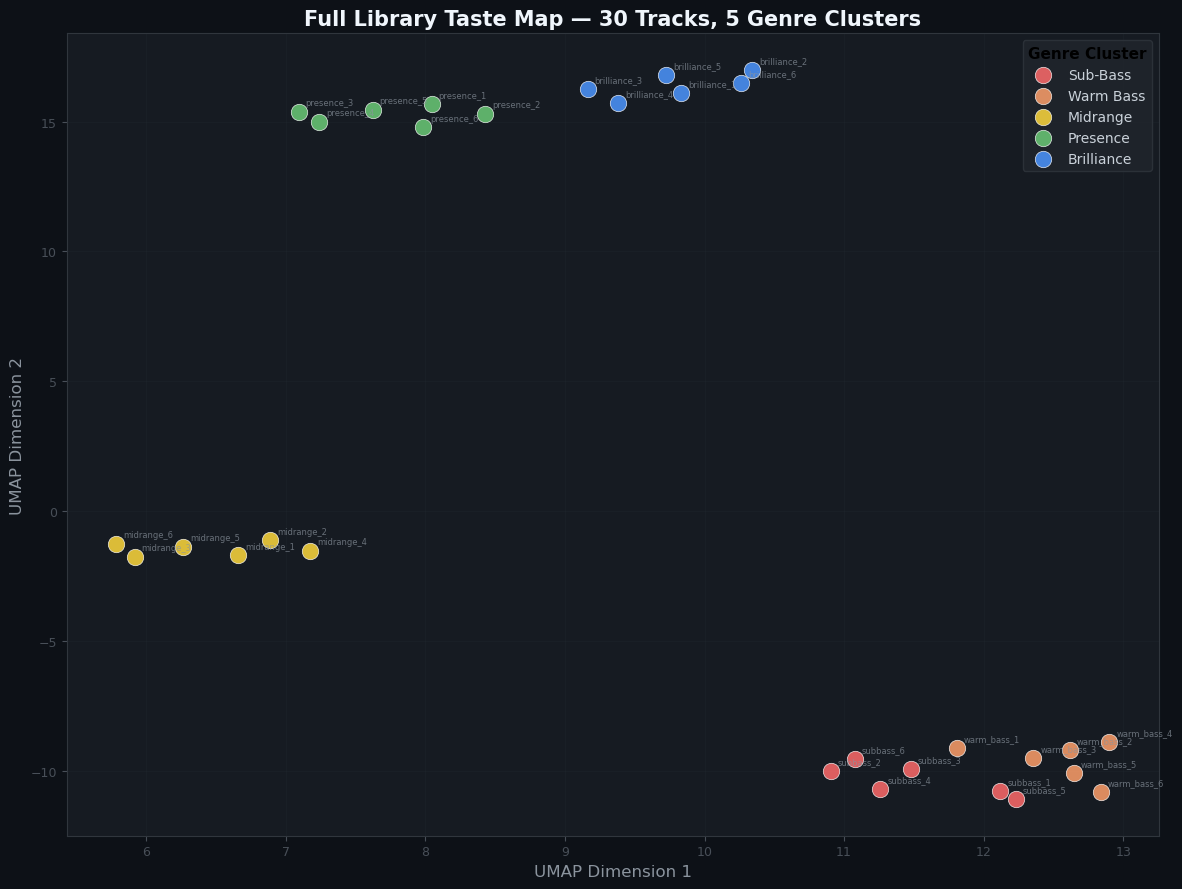

In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 5: UMAP Taste Map (5 clusters)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from src.search.visualizer import compute_umap
from src.search.config import VectorStoreConfig

umap_cfg = VectorStoreConfig(umap_n_neighbors=5, umap_min_dist=0.3)
lib_coords = compute_umap(library_vectors, config=umap_cfg)

# Color palette for 5 genres
palette = {
    "Sub-Bass":   "#ff6b6b",
    "Warm Bass":  "#ffa06b",
    "Midrange":   "#ffd93d",
    "Presence":   "#6bcb77",
    "Brilliance": "#4d96ff",
}

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

for genre, color in palette.items():
    mask = [l == genre for l in library_labels]
    gc = lib_coords[mask]
    
    ax.scatter(gc[:, 0], gc[:, 1], c=color, s=140, alpha=0.85,
               edgecolors="white", linewidths=0.5, label=genre, zorder=3)
    
    # Annotate
    gn = [n for n, m in zip(library_names, mask) if m]
    for j, name in enumerate(gn):
        ax.annotate(name[:12], (gc[j, 0], gc[j, 1]),
                    fontsize=6, color="#8b949e", alpha=0.7,
                    textcoords="offset points", xytext=(5, 5))

ax.set_xlabel("UMAP Dimension 1", color="#8b949e", fontsize=12)
ax.set_ylabel("UMAP Dimension 2", color="#8b949e", fontsize=12)
ax.set_title("Full Library Taste Map — 30 Tracks, 5 Genre Clusters",
             color="#f0f6fc", fontsize=15, fontweight="bold")
ax.legend(facecolor="#21262d", edgecolor="#30363d", labelcolor="#c9d1d9",
          fontsize=10, loc="best", title="Genre Cluster",
          title_fontproperties={"weight": "bold", "size": 11})
ax.tick_params(colors="#484f58", labelsize=9)
for spine in ax.spines.values():
    spine.set_color("#30363d")
ax.grid(True, alpha=0.08, color="#484f58")
plt.tight_layout()
plt.show()

### Interpreting the Taste Map

The UMAP projection reveals the **topology of your musical taste**:

- **Tight clusters** = consistent acoustic profiles within a genre
- **Spacing between clusters** = how acoustically different the genres are
- **Overlap zones** = tracks that bridge two genres (in real music: jazz-funk, synthwave, etc.)
- **Outliers** = tracks that don't fit any cluster — unique sonic signatures

In production with real audio files, you'd see clusters forming around:
- High-energy electronic vs. acoustic ballads
- Vocal-forward tracks vs. instrumental
- Major key (bright) vs. minor key (dark)
- Dense, compressed mixes vs. spacious, dynamic recordings

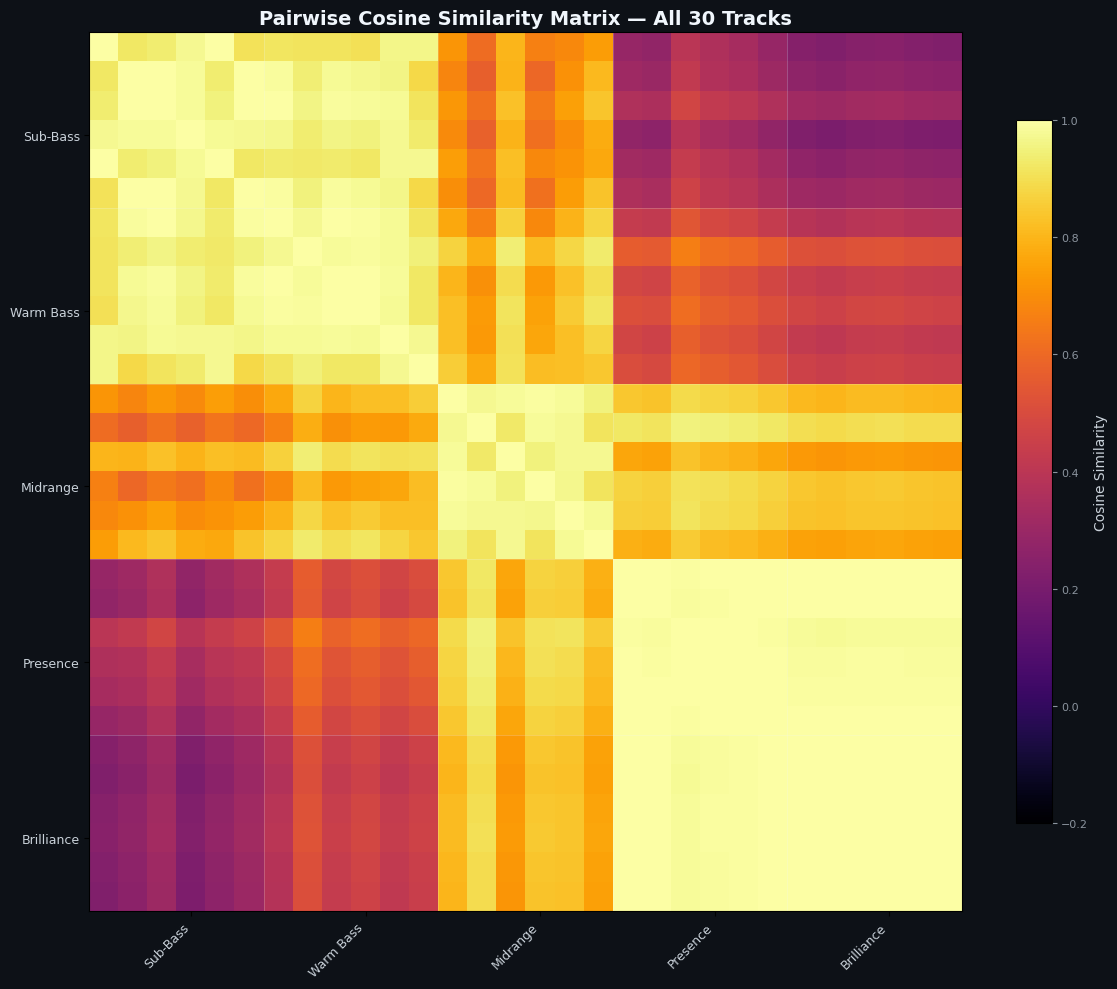

→ Bright blocks on the diagonal = high intra-genre similarity
  Dark off-diagonal blocks = low inter-genre similarity
  This confirms our feature vectors capture meaningful acoustic differences.


In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 6: Similarity Heatmap
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import faiss

# Compute pairwise cosine similarity matrix
vecs_norm = library_vectors.copy()
faiss.normalize_L2(vecs_norm)
sim_matrix = vecs_norm @ vecs_norm.T

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

im = ax.imshow(sim_matrix, cmap="inferno", vmin=-0.2, vmax=1.0, aspect="auto")

# Genre boundary lines
boundaries = [0, 6, 12, 18, 24, 30]
for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="#f0f6fc", linewidth=0.5, alpha=0.3)
    ax.axvline(b - 0.5, color="#f0f6fc", linewidth=0.5, alpha=0.3)

# Genre labels on axes
genre_centers = [3, 9, 15, 21, 27]
genre_names_list = list(genre_specs.keys())
ax.set_xticks(genre_centers)
ax.set_xticklabels(genre_names_list, color="#c9d1d9", fontsize=9, rotation=45, ha="right")
ax.set_yticks(genre_centers)
ax.set_yticklabels(genre_names_list, color="#c9d1d9", fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Cosine Similarity", color="#c9d1d9", fontsize=10)
cbar.ax.tick_params(colors="#8b949e", labelsize=8)

ax.set_title("Pairwise Cosine Similarity Matrix — All 30 Tracks",
             color="#f0f6fc", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("→ Bright blocks on the diagonal = high intra-genre similarity")
print("  Dark off-diagonal blocks = low inter-genre similarity")
print("  This confirms our feature vectors capture meaningful acoustic differences.")

---
## Summary & Next Steps

### What We Built

| Component | Status | Description |
|---|---|---|
| `src/ingestion/` | ✅ Tested | 2026-compliant Spotify API layer with guardrails |
| `src/dsp/` | ✅ Tested | Local DSP feature extraction (77D vectors) |
| `src/search/` | ✅ Tested | FAISS vector index + UMAP visualization |
| **This Notebook** | ✅ Complete | End-to-end walkthrough with working examples |

### Key Design Decisions

1. **Cosine Similarity** over Euclidean distance — magnitude-invariant for audio features
2. **UMAP** over PCA/t-SNE — preserves both local and global topology
3. **Parquet** over CSV — type-safe, columnar compression for high-dimensional data
4. **Bridge Key** (`spotify_track_id`) — universal join across all modules
5. **Guardrails** — proactive blocking of deprecated API calls

### Next Steps

1. **Process Real Audio**: Place `.mp3`/`.wav` files in `data/raw_audio/` and run the full pipeline
2. **Connect to Spotify**: Set up PKCE auth and fetch your actual listening history
3. **Deep Embeddings**: Install `panns-inference` for 2048D neural embeddings (vs. 77D summary vectors)
4. **Production Index**: Swap `IndexFlatIP` for `IndexIVFFlat` when collection exceeds ~50K tracks
5. **Web Dashboard**: Build a Streamlit app around the search module for interactive exploration

### Running the Smoke Tests

```bash
# From the project root:
python -m src.dsp.test_dsp          # 6 tests
python -m src.ingestion.test_ingestion  # 8 tests
python -m src.search.test_search    # 8 tests
```

All 22 tests should pass. If any fail, check your environment against `requirements.txt`.

---
*Built with [librosa](https://librosa.org), [FAISS](https://github.com/facebookresearch/faiss), [UMAP](https://umap-learn.readthedocs.io), and [spotipy](https://spotipy.readthedocs.io).*

*Audio Analytics Pipeline — 2026 Edition*